In [1]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2024_Phase_Camera_FM_Design/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2

from scipy.signal import correlate2d, convolve2d
from scipy.interpolate import RegularGridInterpolator

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


# Effects of FOV on simulation

**Moving completely to thin lens modeling**

*Finding: FWHM of the correlation changes **non-significantly** as FOV increases, however inverse trend still*

* ~~Ensuring proper sampling, wavefield size, and boundary conditions~~
* *Simulate and save phase mask with proper sizes*
    * Try different densities of structures
    * ~~Compare outputs from different samplings~~
* Ensure proper simulation w.r.t. medium RIs
* C~~ompare BPM vs Thin sample modeling~~
    * ~~Make videos for propagation distances~~
* Problem specification: FOV and same sampling, but spatial resolution/ spatial frequency limited by distance and speckle size?
    * ~~Speckle size increases with distance?~~
* Averaging opoerator with stride to map output onto sensor pixels
* Finding minimum sampling frequency: Confirm when sampling frequency starts to effect output

(2000, 2000) float64
[0.0e+00 2.5e-07]


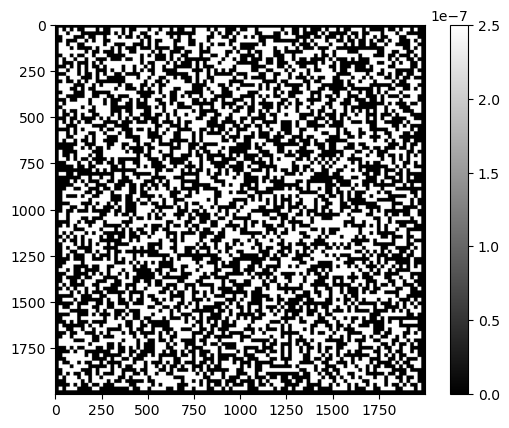

In [16]:
# create phase mask:

# Grid and propagation parameters setup
wl = 640e-9
n_0 = 1.

dx = 500e-9 # dx == dy
nx = 2000 # nx == ny
side_length = 10e-6

tile_size = int(side_length/dx)

h_map = geometry.initialize_hmap_uniform_sampling([nx, nx], tile_size, 250e-9, prob=0.5)

plt.imshow(h_map, cmap='gray')
plt.colorbar()

print(h_map.shape, h_map.dtype)
print(np.unique(h_map))

t = h_map.max()
RI = np.ones_like(h_map)*1.46
opd = h_map*RI + (t-h_map)*n_0

field = np.zeros([nx, nx])
field[:, :] = 10

phase_delay = np.exp(-1j*(2*np.pi/wl)*opd)
phase_delay_bg = np.exp(-1j*(2*np.pi/wl)*(t-h_map)*n_0)

In [20]:
np.unique(phase_delay_bg), np.unique(phase_delay)

(array([-0.77301045-0.63439328j,  1.        +0.j        ]),
 array([-0.90398929+0.42755509j, -0.77301045-0.63439328j]))

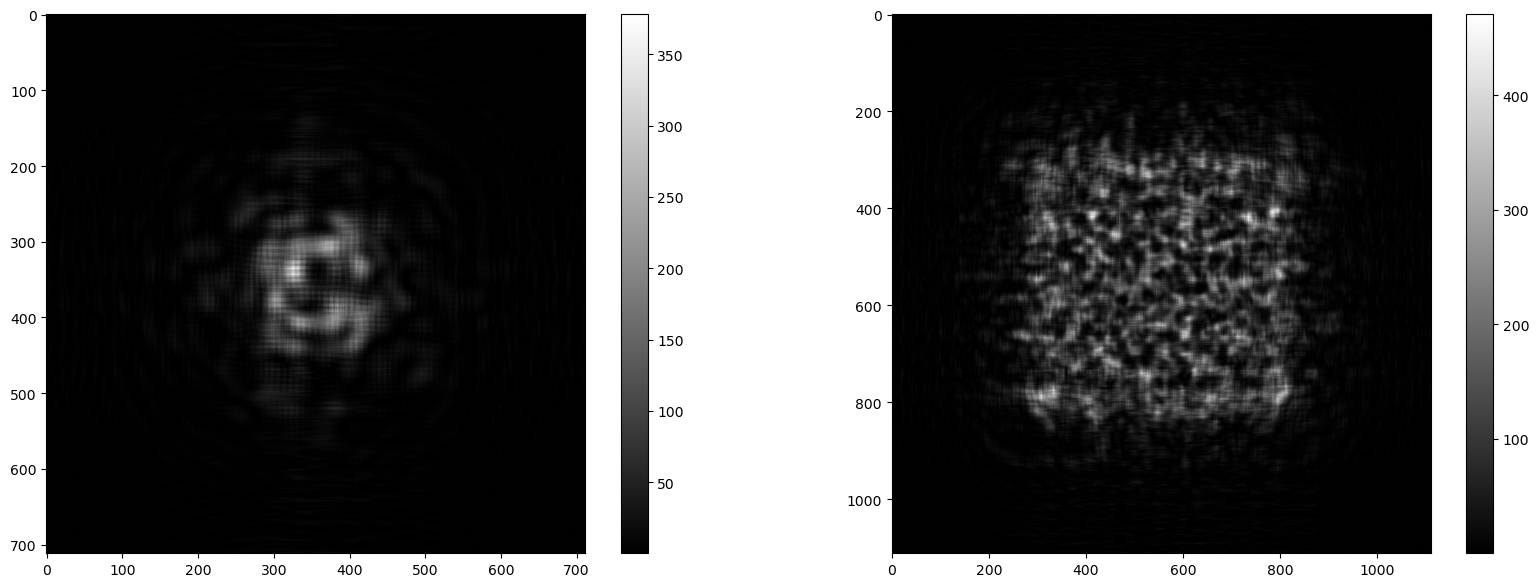

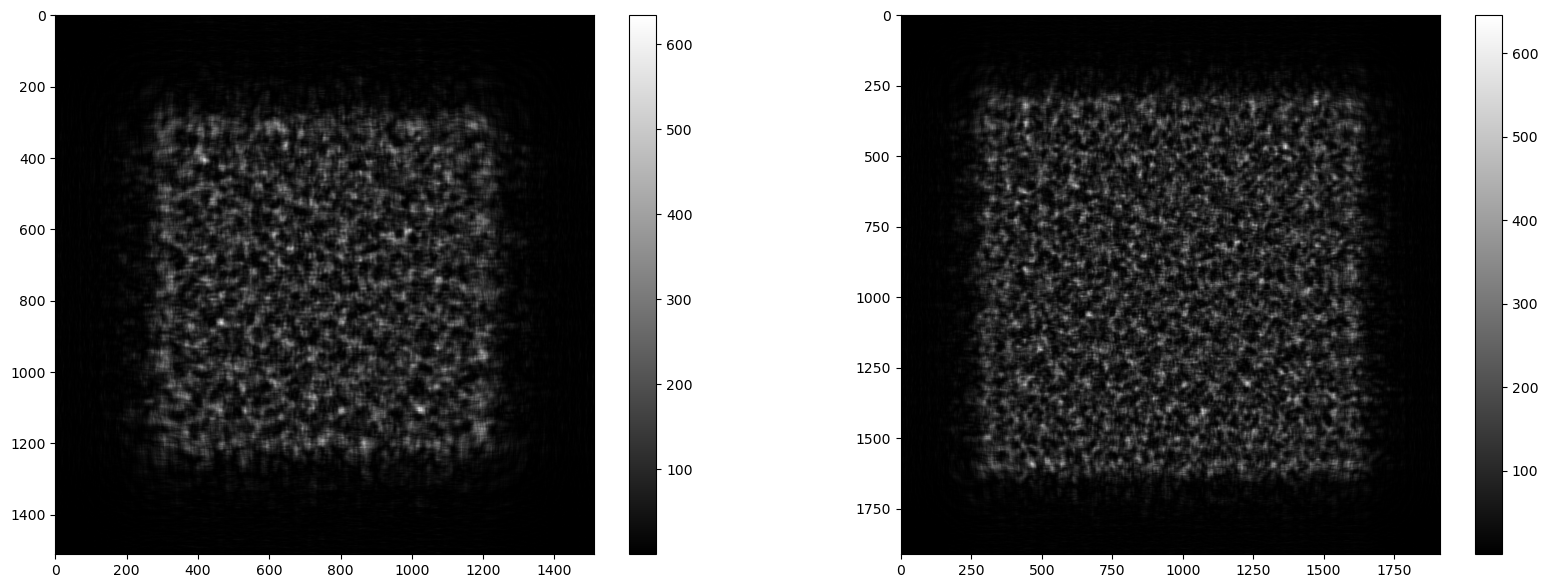

In [29]:
output_field_200 = propagator.propagate(np.pad(field[900:1100, 900:1100]*phase_delay[900:1100, 900:1100], 256, 'constant', constant_values=1), wl/1.49, [dx, dx], 3.e-3, padding=None)
output_field_400 = propagator.propagate(np.pad(field[700:1300, 700:1300]*phase_delay[700:1300, 700:1300], 256, 'constant', constant_values=1), wl/1.49, [dx, dx], 3.e-3, padding=None)
output_field_600 = propagator.propagate(np.pad(field[500:1500, 500:1500]*phase_delay[500:1500, 500:1500], 256, 'constant', constant_values=1), wl/1.49, [dx, dx], 3.e-3, padding=None)
output_field_800 = propagator.propagate(np.pad(field[300:1700, 300:1700]*phase_delay[300:1700, 300:1700], 256, 'constant', constant_values=1), wl/1.49, [dx, dx], 3.e-3, padding=None)

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field_200)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(output_field_400)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field_600)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(output_field_800)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

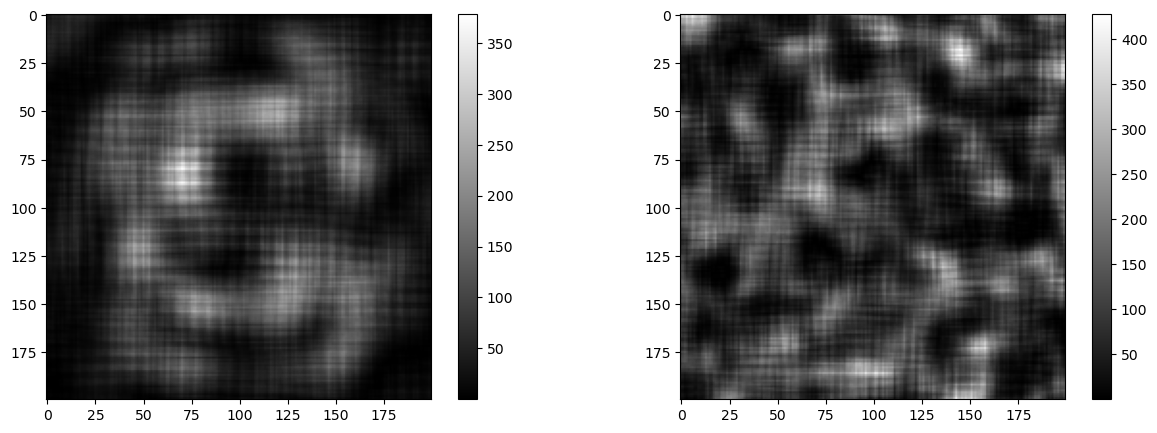

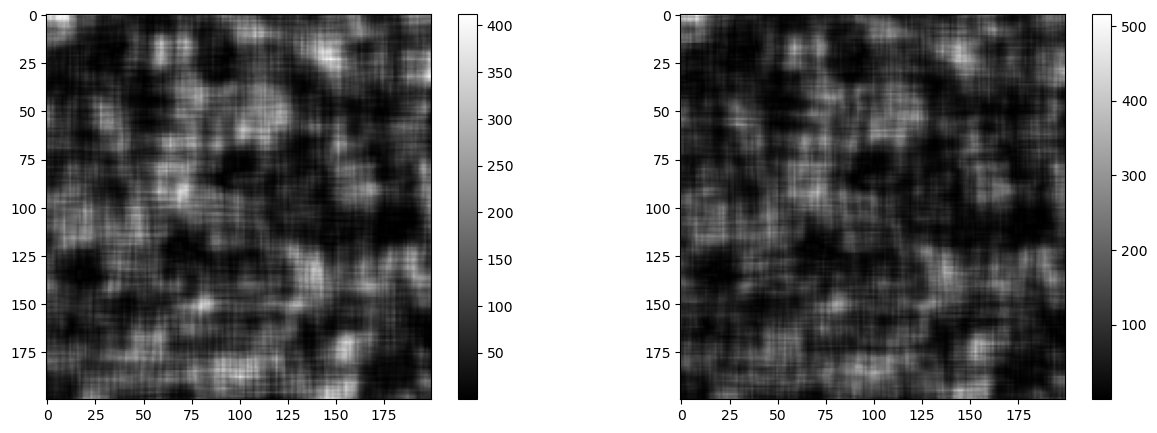

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

z1_patch = output_field_200[256:-256, 256:-256]
z2_patch = output_field_400[256+200:-256-200, 256+200:-256-200]
z3_patch = output_field_600[256+400:-256-400, 256+400:-256-400]
z4_patch = output_field_800[256+600:-256-600, 256+600:-256-600]

cm0 = axs[0].imshow(np.abs(z1_patch)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(z2_patch)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cm0 = axs[0].imshow(np.abs(z3_patch)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(z4_patch)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

In [31]:
corr_z1 = correlate2d(np.abs(z1_patch)**2, np.abs(z1_patch)**2)
corr_z2 = correlate2d(np.abs(z2_patch)**2, np.abs(z2_patch)**2)
corr_z3 = correlate2d(np.abs(z3_patch)**2, np.abs(z3_patch)**2)
corr_z4 = correlate2d(np.abs(z4_patch)**2, np.abs(z4_patch)**2)

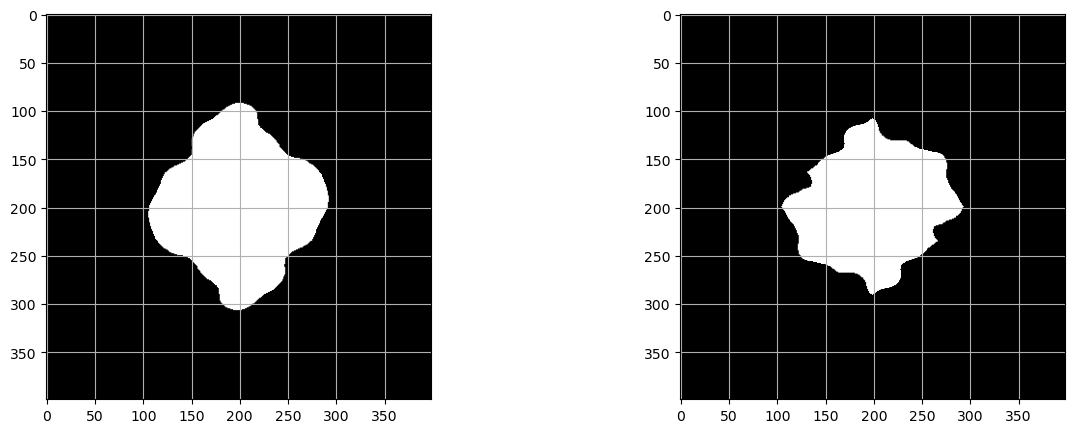

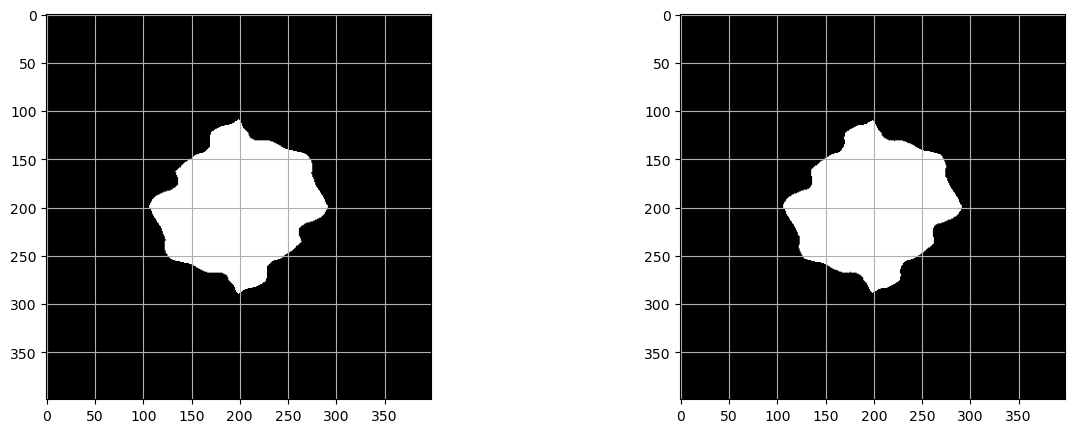

24155
19869
19615
19447


In [32]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cm0 = axs[0].imshow(corr_z1/corr_z1.max() > np.exp(-1), cmap='gray')
axs[0].grid()
# plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(corr_z2/corr_z2.max() > np.exp(-1), cmap='gray')
axs[1].grid()
# plt.colorbar(cm1, ax=axs[1])


plt.show()

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cm0 = axs[0].imshow(corr_z3/corr_z3.max() > np.exp(-1), cmap='gray')
axs[0].grid()
# plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(corr_z4/corr_z4.max() > np.exp(-1), cmap='gray')
axs[1].grid()
# plt.colorbar(cm1, ax=axs[1])


plt.show()

print(np.sum(corr_z1/corr_z1.max() > np.exp(-1)))
print(np.sum(corr_z2/corr_z2.max() > np.exp(-1)))
print(np.sum(corr_z3/corr_z3.max() > np.exp(-1)))
print(np.sum(corr_z4/corr_z4.max() > np.exp(-1)))

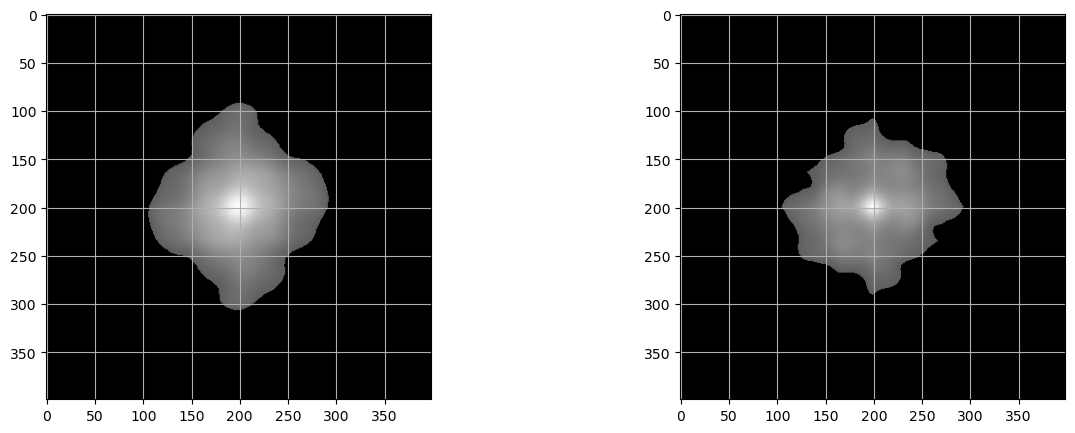

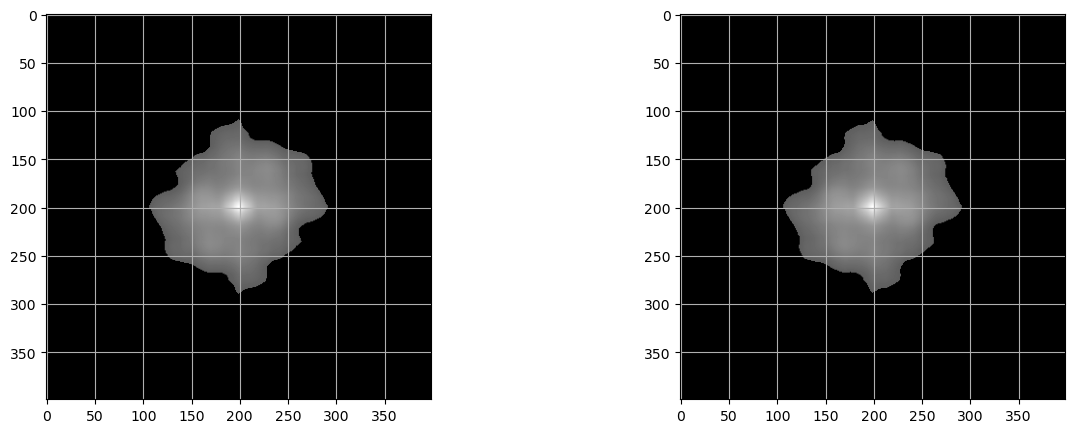

12502.933970334301
9570.01324035373
9426.394121367837
9323.39518068232


In [33]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cm0 = axs[0].imshow(np.where(corr_z1/corr_z1.max() > np.exp(-1), 
                             corr_z1/corr_z1.max(), 0), cmap='gray')
axs[0].grid()
# plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.where(corr_z2/corr_z2.max() > np.exp(-1), 
                             corr_z2/corr_z2.max(), 0), cmap='gray')
axs[1].grid()
# plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

cm0 = axs[0].imshow(np.where(corr_z3/corr_z3.max() > np.exp(-1), 
                             corr_z3/corr_z3.max(), 0), cmap='gray')
axs[0].grid()
# plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.where(corr_z4/corr_z4.max() > np.exp(-1), 
                             corr_z4/corr_z4.max(), 0), cmap='gray')
axs[1].grid()
# plt.colorbar(cm1, ax=axs[1])

plt.show()

print(np.sum(np.where(corr_z1/corr_z1.max() > np.exp(-1), corr_z1/corr_z1.max(), 0)))
print(np.sum(np.where(corr_z2/corr_z2.max() > np.exp(-1), corr_z2/corr_z2.max(), 0)))
print(np.sum(np.where(corr_z3/corr_z3.max() > np.exp(-1), corr_z3/corr_z3.max(), 0)))
print(np.sum(np.where(corr_z4/corr_z4.max() > np.exp(-1), corr_z4/corr_z4.max(), 0)))

In [1]:
# cap = cv2.VideoCapture(0)

# # Define the codec and create VideoWriter object
# #fourcc = cv2.cv.CV_FOURCC(*'DIVX')
# #out = cv2.VideoWriter('output.avi',fourcc, 20.0, (640,480))
# out = cv2.VideoWriter('v9/v9_3/10um_250nm_2_mask_prop_abs.avi', cv2.VideoWriter_fourcc(*'XVID'), 20, (200, 200), isColor=False)

# for i in range(1, 3000, 10):
#     frame = propagator.propagate(field*phase_delay, wl/1.49, [dx, dx], i*1e-6, padding=256)
    
#     frame = np.abs(frame)**2
#     # frame = convolve2d(frame, np.ones([10, 10]), mode='valid')[::10, ::10]
#     frame = np.array(((frame - frame.min())/(frame.max() - frame.min()))*255, dtype=np.uint8)

#     # write the flipped frame
#     out.write(frame)

# # Release everything if job is finished
# out.release()

In [55]:
frame.shape, 2000*500e-9/1e-3

((200, 200), 1.0)